## Pre-processing data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from tqdm.notebook import tqdm

plt.rcParams.update({'font.size': 14})
sns.set_style('whitegrid')

In [2]:
#!pip install torchdata

In [3]:
# ! kaggle datasets download lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
# ! unzip imdb-dataset-of-50k-movie-reviews.zip

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
df = pd.read_csv("./IMDB Dataset.csv").rename({"review": "raw_text", "sentiment": "target"}, axis=1)
df["target"] = (df["target"] == "positive").astype(int)
df

,raw_text,target
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1
...,...,...
49995,I thought this movie did a down right good job...,1
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",0
49997,I am a Catholic taught in parochial elementary...,0
49998,I'm going to have to disagree with the previou...,0


In [6]:
train_set, test_set = train_test_split(df, test_size=1/2, random_state=42, stratify=df["target"].values)
train_set = train_set.reset_index(drop=True)
test_set = test_set.reset_index(drop=True)

train_set.shape, test_set.shape

((25000, 2), (25000, 2))

In [7]:
train_set.head()

,raw_text,target
0,Trio's vignettes were insightful and quite enj...,1
1,I had never heard of this one before the owner...,0
2,This is an excellent but hard to find trippy W...,1
3,"I am a huge fan of big, loud, trashy, complete...",1
4,"Easily Lucio Fulci's most respected film, ""Don...",1


In [8]:
train_set['target'].value_counts()

target
1    12500
0    12500
Name: count, dtype: int64

In [9]:
test_set['target'].value_counts()

target
0    12500
1    12500
Name: count, dtype: int64

In [10]:
train_set.loc[101]['raw_text']

'This is an unusual film because although it was made by Twentieth-Century Fox because it\'s one of the few pairings of Barbara Stanwyck and her future husband, Robert Taylor. Barbara Stanwyck had been making films for many different studios (RKO, Paramount and Selznick) at about the time she made THIS IS MY AFFAIR, but Taylor was an MGM contract player so he only appeared in this film because he was loaned to Fox--something studios occasionally did during this era.<br /><br />The film is interesting because many real-life people have roles in the film, though the piece is otherwise pure fiction. You\'ll see actors playing William McKinley, Teddy Roosevelt and Admiral Dewey. I can\'t recall any film with McKinley or Dewey in it as a character, though I do remember Roosevelt from THE WIND AND THE LION and a couple other films. Three cheers for seeing a "lesser President" in a film as a major character! <br /><br />The film begins with McKinley taking a young lieutenant (Robert Taylor) a

In [11]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

Lemmatization of the texts:

In [12]:
nltk.download('omw-1.4')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('punkt_tab')


stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package omw-1.4 to /home/fvelikon/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to /home/fvelikon/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /home/fvelikon/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/fvelikon/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/fvelikon/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [13]:
def preprocess(text):
    text = list(filter(str.isalpha, word_tokenize(text.lower())))
    text = list(lemmatizer.lemmatize(word) for word in text)
    text = list(word for word in text if word not in stop_words)
    return ' '.join(text)

In [14]:
train_set['text'] = train_set.apply(lambda row: preprocess(row.raw_text), axis=1)
test_set['text'] = test_set.apply(lambda row: preprocess(row.raw_text), axis=1)

In [15]:
train_set.loc[101]['text']

'unusual film although wa made fox one pairing barbara stanwyck future husband robert taylor barbara stanwyck making film many different studio rko paramount selznick time made affair taylor wa mgm contract player appeared film wa loaned fox something studio occasionally br br film interesting many people role film though piece otherwise pure fiction see actor playing william mckinley teddy roosevelt admiral dewey ca recall film mckinley dewey character though remember roosevelt wind lion couple film three cheer seeing lesser president film major character br br film begin mckinley taking young lieutenant robert taylor aside asking special agent telling one even secret service president fear someone within agency tipping gang ha making long string robbery based inside information taylor known manly role especially stage career pose thug find gang responsible inside br br however two serious complication first able find gang member one gang member stanwyck taylor find fallen love must a

## Baseline

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [17]:
tf_idf = TfidfVectorizer().fit(train_set['text'])
train_tf_idf = tf_idf.transform(train_set['text'])
test_tf_idf = tf_idf.transform(test_set['text'])

In [18]:
log_regr = LogisticRegression(n_jobs=-1).fit(train_tf_idf, train_set['target'])

In [19]:
print(f'Train acc: {accuracy_score(train_set["target"],log_regr.predict(train_tf_idf)):.4f}')
print(f'Test acc: {accuracy_score(test_set["target"], log_regr.predict(test_tf_idf)):.4f}')

Train acc: 0.9322
Test acc: 0.8856


In [20]:
log_regr.coef_.shape

(1, 64947)

## Tokenizing data

In [21]:
from torchtext.vocab import build_vocab_from_iterator

def dataset_iterator(texts):
    for text in texts:
        yield text.split()

/home/fvelikon/miniconda3/envs/hse_nlp_gpu/lib/python3.10/site-packages/torchtext/vocab/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/home/fvelikon/miniconda3/envs/hse_nlp_gpu/lib/python3.10/site-packages/torchtext/utils.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)


In [22]:
vocab = build_vocab_from_iterator(
    dataset_iterator(train_set['text']),
    specials=['<pad>', '<unk>'], min_freq=10,
)

In [23]:
train_tokens = []
for text in dataset_iterator(train_set['text']):
    tokens = [vocab[word] if word in vocab else vocab['<unk>'] for word in text]
    train_tokens += [tokens]

test_tokens = []
for text in dataset_iterator(test_set['text']):
    tokens = [vocab[word] if word in vocab else vocab['<unk>'] for word in text]
    test_tokens += [tokens]

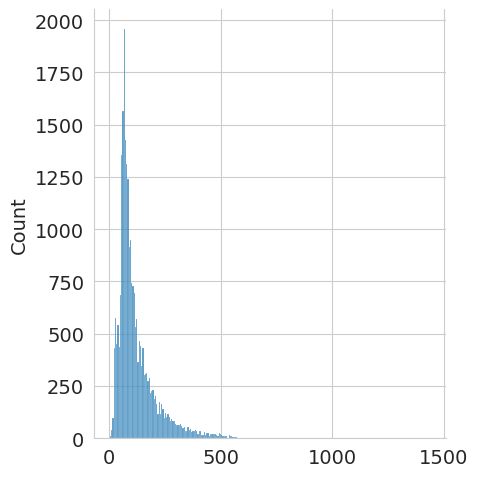

In [24]:
lengths = np.array([len(tokens) for tokens in train_tokens])
sns.displot(lengths)
plt.show()

In [25]:
max_length = 256
tokenized_train = torch.full((len(train_tokens), max_length), vocab['<pad>'], dtype=torch.int32)
for i, tokens in enumerate(train_tokens):
    length = min(max_length, len(tokens))
    tokenized_train[i, :length] = torch.tensor(tokens[:length])

tokenized_test = torch.full((len(test_tokens), max_length), vocab['<pad>'], dtype=torch.int32)
for i, tokens in enumerate(test_tokens):
    length = min(max_length, len(tokens))
    tokenized_test[i, :length] = torch.tensor(tokens[:length])

In [26]:
targets_train = torch.tensor(train_set['target'].values, dtype=torch.int32)
targets_test = torch.tensor(test_set['target'].values, dtype=torch.int32)

In [27]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(tokenized_train, targets_train)
test_dataset = TensorDataset(tokenized_test, targets_test)

batch_size = 256
train_loader = DataLoader(train_dataset, batch_size, shuffle=True, num_workers=12, pin_memory=True, prefetch_factor=6)
test_loader = DataLoader(test_dataset, batch_size, shuffle=False, num_workers=12, pin_memory=True, prefetch_factor=6)

## Transformer architecture

In [28]:
import math
from torch import nn

class PositionalEncoder(nn.Module):
    # Adapted from: https://pytorch.org/tutorials/beginner/transformer_tutorial.html

    def __init__(self, max_length, embed_dim, dropout):
        super().__init__()
        self.pos_features = torch.zeros(max_length, embed_dim)

        positions = torch.arange(0, max_length, dtype=torch.float).unsqueeze(1)
        freqs = torch.exp(torch.arange(0, embed_dim, 2, dtype=torch.float) * (-math.log(10000) / embed_dim)).unsqueeze(0)
        print(freqs)

        arguments = positions * freqs
        self.pos_features[:, 0::2] = torch.sin(arguments)
        self.pos_features[:, 1::2] = torch.cos(arguments)
        self.pos_features = self.pos_features.unsqueeze(0)
        self.pos_features = nn.Parameter(self.pos_features, requires_grad=True)
        # pos_features: (1, max_length, embed_dim)

        self.dropout = nn.Dropout(dropout)

    def forward(self, inputs):
        outputs = inputs + self.pos_features[:, :inputs.shape[1]]
        return self.dropout(outputs)

![](https://jalammar.github.io/images/t/self-attention-matrix-calculation-2.png)

In [29]:
torch.cuda.is_available()

True

In [30]:
class Attention(nn.Module):
    # Single-head attention
    def __init__(self, embed_dim, num_heads, dropout):
        super().__init__()
        attention_dim = embed_dim // num_heads

        self.WQ = nn.Linear(embed_dim, attention_dim, bias=False)
        self.WK = nn.Linear(embed_dim, attention_dim, bias=False)
        self.WV = nn.Linear(embed_dim, attention_dim, bias=False)
        self.dropout = nn.Dropout(dropout)

        self.norm_factor = math.sqrt(attention_dim)

    def forward(self, query, key, value, mask=None):
        # query, key, value: (batch_size, length, embed_dim)
        # mask: (batch_size, length, length)

        Q = self.WQ(query)
        K = self.WK(key)
        V = self.WV(value)
        # Q, K, V: (batch_size, length, attention_dim)

        dot_products = torch.bmm(Q, K.transpose(1, 2)) / self.norm_factor
        # dot_products: (batch_size, length, length)

        if mask is not None:
            dot_products = dot_products.masked_fill(mask, -math.inf)

        attention_score = nn.functional.softmax(dot_products, dim=-1)
        attention = torch.bmm(self.dropout(attention_score), V)
        # attention_score: (batch_size, length, length)
        # attention: (batch_size, length, attention_dim)

        return attention, attention_score


class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout):
        super(MultiHeadAttention, self).__init__()

        assert embed_dim % num_heads == 0
        self.attention_heads = nn.ModuleList([Attention(embed_dim, num_heads, dropout)
                                              for _ in range(num_heads)])

        self.linear = nn.Linear(embed_dim, embed_dim, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key, value, mask=None):
        # query, key, value: (batch_size, length, embed_dim)
        # mask: (batch_size, length, length)
        attentions, attention_scores = [], []

        for head in self.attention_heads:
            attention, attention_score = head(query, key, value, mask)
            attentions += [attention]
            attention_scores += [attention_score]

        attentions = torch.cat(attentions, dim=-1)
        attention_scores = torch.stack(attention_scores, dim=-1)
        # attentions: (batch_size, length, embed_dim)
        # attention_scores: (batch_size, length, length, num_heads)

        outputs = self.linear(attentions)
        outputs = self.dropout(outputs)
        # outputs: (batch_size, length, embed_dim)

        return outputs, attention_scores

In [31]:
def create_padding_mask(tokens, pad_idx=vocab['<pad>']):
    # tokens: (batch_size, length)
    length = tokens.shape[-1]
    padding_mask = (tokens == pad_idx)
    padding_mask = padding_mask.unsqueeze(1).repeat(1, length, 1)
    # padding_mask: (batch_size, length, length)

    return padding_mask

In [32]:
class TransformerLayer(nn.Module):
    def __init__(self, embed_dim, fc_dim, num_heads, dropout):
        super().__init__()
        self.self_attention = MultiHeadAttention(embed_dim, num_heads, dropout)
        self.feedforward = nn.Sequential(
            nn.Linear(embed_dim, fc_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(fc_dim, embed_dim),
            nn.Dropout(dropout)
        )
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, inputs, mask):
        attention, attention_score = self.self_attention(query=inputs, key=inputs, 
                                                         value=inputs, mask=mask)
        outputs = inputs + attention
        outputs = self.norm1(outputs)
        outputs = outputs + self.feedforward(outputs)
        outputs = self.norm2(outputs)
        return outputs, attention_score


class Transformer(nn.Module):
    def __init__(self, vocab_size, max_length, num_classes,
                 embed_dim, fc_dim, num_heads, num_layers, dropout):
        super().__init__()
        self.embed_dim = embed_dim
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.pos_encoder = PositionalEncoder(max_length, embed_dim, dropout)
        self.layers = nn.ModuleList([TransformerLayer(embed_dim, fc_dim, num_heads, dropout) \
                                     for _ in range(num_layers)])
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, tokens):
        # source: (batch_size, length)
        embeds = self.embedding(tokens) * math.sqrt(self.embed_dim)
        outputs = self.pos_encoder(embeds)
        # outputs: (batch_size, length, embed_dim)

        padding_mask = create_padding_mask(tokens)
        attention_scores = []
        for layer in self.layers:
            outputs, attention_score = layer(outputs, padding_mask)
            attention_scores += [attention_score]
        attention_scores = torch.stack(attention_scores, dim=-1)
        # outputs: (batch_size, length, embed_dim)
        # attentions_scores: (batch_size, length, embed_dim, num_heads, num_layers)

        mask = (tokens != vocab['<pad>']).to(torch.float).detach()
        lengths = mask.sum(dim=1).detach()
        outputs = (outputs * mask.unsqueeze(2)).sum(dim=1) / lengths.unsqueeze(1)
        # outputs: (batch_size, embed_dim)

        logits = self.classifier(outputs)
        # logits: (batch_size, num_classes)

        return logits, attention_scores

In [33]:
from IPython.display import clear_output

def plot_losses(train_losses, test_losses, train_accuracies, test_accuracies):
    clear_output()
    fig, axs = plt.subplots(1, 2, figsize=(13, 4))
    axs[0].plot(range(1, len(train_losses) + 1), train_losses, label='train')
    axs[0].plot(range(1, len(test_losses) + 1), test_losses, label='test')
    axs[0].set_ylabel('loss')

    axs[1].plot(range(1, len(train_accuracies) + 1), train_accuracies, label='train')
    axs[1].plot(range(1, len(test_accuracies) + 1), test_accuracies, label='test')
    axs[1].set_ylabel('accuracy')

    for ax in axs:
        ax.set_xlabel('epoch')
        ax.legend()

    plt.show()

In [34]:
num_epochs = 20

Learning rate scheduler with warmup

In [35]:
class TransformerLRScheduler():
    '''A simple wrapper class for learning rate scheduling - adapted from https://github.com/jadore801120/attention-is-all-you-need-pytorch/blob/132907dd272e2cc92e3c10e6c4e783a87ff8893d/transformer/Optim.py#L4'''

    def __init__(self, optimizer, lr_mul, d_model, n_warmup_steps):
        self._optimizer = optimizer
        self.lr_mul = lr_mul
        self.d_model = d_model
        self.n_warmup_steps = n_warmup_steps
        self.n_steps = 0

        self._lr_history = []

    def step_and_update_lr(self):
        """Step with the inner optimizer"""
        self._update_learning_rate()
        self._optimizer.step()


    def zero_grad(self):
        """Zero out the gradients with the inner optimizer"""
        self._optimizer.zero_grad()


    def _get_lr_scale(self):

        return (self.d_model ** -0.5) * min(self.n_steps ** (-0.5), self.n_steps * self.n_warmup_steps ** (-1.5))


    def _update_learning_rate(self):
        ''' Learning rate scheduling per step '''

        self.n_steps += 1
        lr = self.lr_mul * self._get_lr_scale()
        
        for param_group in self._optimizer.param_groups:
            param_group['lr'] = lr

        self._lr_history.append(lr)

In [36]:
torch.cuda.empty_cache()

In [37]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = Transformer(vocab_size=len(vocab), max_length=max_length, num_classes=1,
                    embed_dim=128, fc_dim=128, num_heads=8, num_layers=8, dropout=0.2).to(device)

model = torch.compile(model, dynamic=True)  # <-------       USE CAREFULLY!!!!!!!

optimizer = torch.optim.Adam(model.parameters(), lr=1e-1)

d_model = 128 // 4  # (embed_dim // num_heads)

lr_scheduler = TransformerLRScheduler(optimizer=optimizer,
                                      d_model=d_model,
                                      n_warmup_steps=(num_epochs // 3) * len(train_loader),  # ~33% of the training for warmup
                                      lr_mul=1e-1)
criterion = nn.BCEWithLogitsLoss()

tensor([[1.0000e+00, 8.6596e-01, 7.4989e-01, 6.4938e-01, 5.6234e-01, 4.8697e-01,
         4.2170e-01, 3.6517e-01, 3.1623e-01, 2.7384e-01, 2.3714e-01, 2.0535e-01,
         1.7783e-01, 1.5399e-01, 1.3335e-01, 1.1548e-01, 1.0000e-01, 8.6596e-02,
         7.4989e-02, 6.4938e-02, 5.6234e-02, 4.8697e-02, 4.2170e-02, 3.6517e-02,
         3.1623e-02, 2.7384e-02, 2.3714e-02, 2.0535e-02, 1.7783e-02, 1.5399e-02,
         1.3335e-02, 1.1548e-02, 1.0000e-02, 8.6596e-03, 7.4989e-03, 6.4938e-03,
         5.6234e-03, 4.8697e-03, 4.2170e-03, 3.6517e-03, 3.1623e-03, 2.7384e-03,
         2.3714e-03, 2.0535e-03, 1.7783e-03, 1.5399e-03, 1.3335e-03, 1.1548e-03,
         1.0000e-03, 8.6596e-04, 7.4989e-04, 6.4938e-04, 5.6234e-04, 4.8697e-04,
         4.2170e-04, 3.6517e-04, 3.1623e-04, 2.7384e-04, 2.3714e-04, 2.0535e-04,
         1.7783e-04, 1.5399e-04, 1.3335e-04, 1.1548e-04]])


In [38]:
sum(param.numel() for param in model.parameters())

3026177

## Training

In [39]:
train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []


for epoch in range(1, num_epochs + 1):
    model.train()
    running_loss, running_accuracy = 0.0, 0.0
    for tokens, labels in tqdm(train_loader, desc=f'Training {epoch}/{num_epochs}'):
        tokens = tokens.to(device)
        labels = labels.to(device)
        
        logits, _ = model(tokens)
        logits = logits.squeeze(1)

        probs = torch.sigmoid(logits)
        loss = criterion(logits, labels.to(torch.float))
        loss.backward()
        lr_scheduler.step_and_update_lr()  # includes optimizer step
        optimizer.zero_grad()

        running_loss += loss.item() * tokens.shape[0]
        running_accuracy += ((probs > 0.5).to(torch.int) == labels).sum().item()

    
    train_losses += [running_loss / len(train_loader.dataset)]
    train_accuracies += [running_accuracy / len(train_loader.dataset)]
    
    model.eval()
    running_loss, running_accuracy = 0.0, 0.0
    for tokens, labels in tqdm(test_loader, desc=f'Testing {epoch}/{num_epochs}'):
        tokens = tokens.to(device)
        labels = labels.to(device)
        
        with torch.no_grad():
            logits, _ = model(tokens)
            logits = logits.squeeze(1)
            probs = torch.sigmoid(logits)
            loss = criterion(logits, labels.to(torch.float))
        
        running_loss += loss.item() * tokens.shape[0]
        running_accuracy += ((probs > 0.5).to(torch.int) == labels).sum().item()
        
    test_losses += [running_loss / len(test_loader.dataset)]
    test_accuracies += [running_accuracy / len(test_loader.dataset)]
    plot_losses(train_losses, test_losses, train_accuracies, test_accuracies)

print(f'Best test accuracy: {max(test_accuracies)}')

Training 1/20:   0%|          | 0/98 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 32.00 MiB. GPU 

: 

In [ ]:
# !pip install plotly
# !pip install -U nbformat>=4.2.0

In [ ]:
import plotly.express as px

px.line(y=lr_scheduler._lr_history, title="Learning rate dynamics")

## Visualizing attention scores

In [ ]:
for tokens, labels in train_loader:
    tokens = tokens.to(device)
    labels = labels.to(device)
    break

In [ ]:
tokens = tokens[:1]
tokens

In [ ]:
(tokens != 0).sum()

In [ ]:
tokens = tokens[:, :(tokens != 0).sum().item()]

In [ ]:
with torch.no_grad():
    logits, scores = model(tokens)

In [ ]:
fig, axs = plt.subplots(4, 4, figsize=(12, 12))

for i in range(4):
    axs[i, 0].set_ylabel(f'Head #{i + 1}')
    axs[-1, i].set_xlabel(f'Layer #{i + 1}')
    for j in range(4):
        axs[i, j].imshow(scores[0, ..., i, j].cpu().numpy())
        axs[i, j].grid()
        axs[i, j].xaxis.set_ticks([])
        axs[i, j].yaxis.set_ticks([])

plt.tight_layout()
plt.show()

In [ ]:
words = [vocab.get_itos()[token] for token in tokens.squeeze().cpu().numpy()]

In [ ]:
scores

In [ ]:
scores[0, ..., 2, 0].shape

In [ ]:
fig, ax = plt.subplots(figsize=(30, 30))

plt.imshow(scores[0, ..., 2, 0].cpu().numpy())
ax.set_xticks(range(len(words)))
ax.set_xticklabels(words, rotation=90)
ax.set_yticks(range(len(words)))
ax.set_yticklabels(words)

plt.grid()
plt.show()